In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# Define Autoencoder
encoding_dim = 32  # Bottleneck size

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)

# Compile & Train
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2281 - val_loss: 0.1521
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1347 - val_loss: 0.1206
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1155 - val_loss: 0.1085
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1065 - val_loss: 0.1021
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1019 - val_loss: 0.0988
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0992 - val_loss: 0.0966
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0974 - val_loss: 0.0952
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0959 - val_loss: 0.0940
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0947 - val_loss: 0.0929
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0936 - val_loss: 0.0921


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


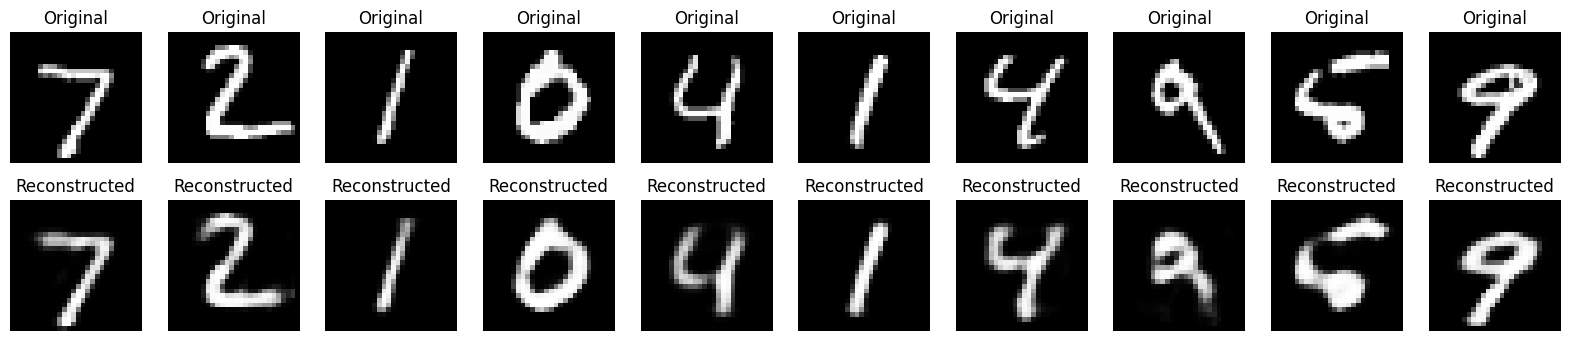

In [2]:
# Encode & Decode test images
decoded_imgs = autoencoder.predict(x_test)

# Display original vs reconstructed
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add random noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Flatten images
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
x_train_noisy = x_train_noisy.reshape((len(x_train_noisy), 784))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy), 784))

# Define Autoencoder
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train with noisy input but clean target
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# Predict on noisy test images
decoded_imgs = autoencoder.predict(x_test_noisy)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2457 - val_loss: 0.1816
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1666 - val_loss: 0.1534
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1482 - val_loss: 0.1417
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1394 - val_loss: 0.1349
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1337 - val_loss: 0.1301
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1296 - val_loss: 0.1272
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1268 - val_loss: 0.1247
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1247 - val_loss: 0.1231
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1229 - val_loss: 0.1219
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1215 - val_loss: 0.1211
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


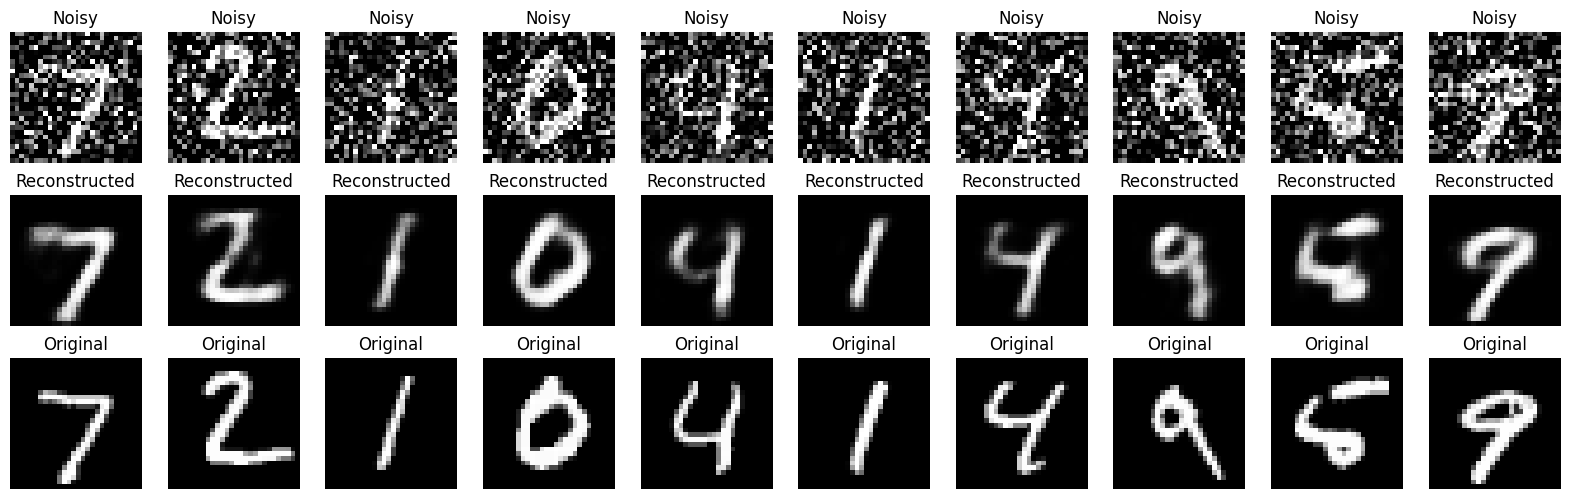

In [5]:
# Compare noisy input, reconstructed output, and original clean images
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
     )
    
    # Noisy input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed output
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
  # Original clean image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off"
 

plt.show()


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Example dataset: CIFAR-10 (color images)
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert to grayscale (input) and keep original color (target)
x_train_gray = np.dot(x_train[...,:3], [0.299, 0.587, 0.114])[..., np.newaxis]
x_test_gray = np.dot(x_test[...,:3], [0.299, 0.587, 0.114])[..., np.newaxis]

# Define Autoencoder
input_img = layers.Input(shape=(32, 32, 1))   # grayscale input
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)  # RGB output

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train: grayscale → color
autoencoder.fit(x_train_gray, x_train,
                epochs=20,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_gray, x_test))

# Predict on test grayscale images
decoded_imgs = autoencoder.predict(x_test_gray)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 66s 161ms/step - loss: 0.0142 - val_loss: 0.0099
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - loss: 0.0092 - val_loss: 0.0085
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 139ms/step - loss: 0.0083 - val_loss: 0.0079
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 149ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 160ms/step - loss: 0.0075 - val_loss: 0.0072
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 151ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 167ms/step - loss: 0.0071 - val_loss: 0.0068
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - loss: 0.0070 - val_loss: 0.0067
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 147ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - loss: 0.0067 - val_loss: 0.0065
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 147ms/step - loss: 0.0066 - val_loss: 0.0069
Epoch 12/20
391/391

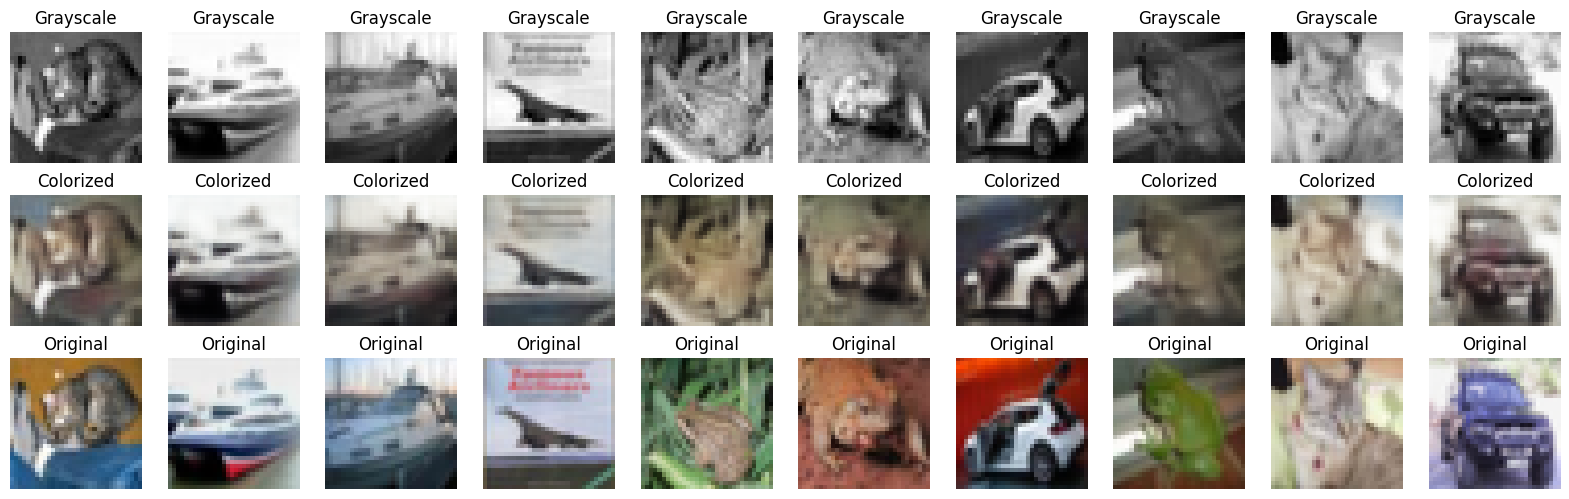

In [7]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Grayscale input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_gray[i].reshape(32, 32), cmap='gray')
    plt.title("Grayscale")
    plt.axis("off")

    # Reconstructed color
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Colorized")
    plt.axis("off")

    # Original color
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

latent_dim = 2  # small latent space for visualization

# Encoder
inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Reparameterization
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

# Decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(28*28, activation='sigmoid')(x)
outputs = layers.Reshape((28,28,1))(x)
decoder = Model(decoder_input, outputs)

# VAE Model
outputs = decoder(z)
vae = Model(inputs, outputs)

# Loss
reconstruction_loss = tf.reduce_mean(
    tf.keras.losses.binary_crossentropy(tf.reshape(inputs, [-1, 28*28]),
                                        tf.reshape(outputs, [-1, 28*28]))
)
kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
vae.add_loss(reconstruction_loss + kl_loss)
vae.compile(optimizer='adam')

# Train
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
vae.fit(x_train, x_train, epochs=10, batch_size=128)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample random points from latent space
n = 15  # number of digits per row/column
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Grid of latent space values
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.title("Generated digits from VAE latent space")
plt.axis("off")
plt.show()
